# Title

## Module Imports

In [ ]:
from dataclasses import dataclass
from typing import Callable
import pickle
import mlflow
import nico2_lib as n2l
import matplotlib.pyplot as plt
import numpy as np
from numpy import number
from numpy.typing import NDArray
import polars as pl
import seaborn as sns
from create_table import build_metric_registry, build_tidy_aggregated_scores_df
from experiment import (
    DatasetDimension,
    CelltypeDimension,
    ExperimentResult,
    ModelDimension,
    ResultRecord,
    SampleDimension,
)

In [2]:
benchmark_experiment = mlflow.get_experiment_by_name("Default")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]

2026/02/20 15:03:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/20 15:03:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/20 15:03:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/20 15:03:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/20 15:03:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/20 15:03:32 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/20 15:03:32 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/20 15:03:32 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [6]:
artifact_path = mlflow.artifacts.download_artifacts(
    run_id=last_run_id, artifact_path="results.pkl"
)
with open(artifact_path, "rb") as f:
    results = pickle.load(f)

In [8]:
metric_registry = build_metric_registry()
df = build_tidy_aggregated_scores_df(results, metric_registry)
df

dataset_name,model_name,prediction_scope,sample_idx,metric_name,aggregation,score,n_celltypes,total_cells
str,str,str,i64,str,str,f64,i64,i64
"""small_mouse_intestine_spatial""","""NMF_3""","""celltype""",0,"""pearsonr""","""macro""",0.445172,17,7411
"""small_mouse_intestine_spatial""","""NMF_3""","""celltype""",0,"""pearsonr""","""weighted""",0.52904,17,7411
"""small_mouse_intestine_spatial""","""NMF_3""","""celltype""",0,"""spearmanr""","""macro""",0.374839,17,7411
"""small_mouse_intestine_spatial""","""NMF_3""","""celltype""",0,"""spearmanr""","""weighted""",0.427635,17,7411
"""small_mouse_intestine_spatial""","""NMF_3""","""celltype""",1,"""pearsonr""","""macro""",0.509419,17,7411
…,…,…,…,…,…,…,…,…
"""small_mouse_intestine_spatial""","""NMF_8""","""global""",8,"""spearmanr""","""weighted""",0.289761,17,7411
"""small_mouse_intestine_spatial""","""NMF_8""","""global""",9,"""pearsonr""","""macro""",0.261027,17,7411
"""small_mouse_intestine_spatial""","""NMF_8""","""global""",9,"""pearsonr""","""weighted""",0.285538,17,7411


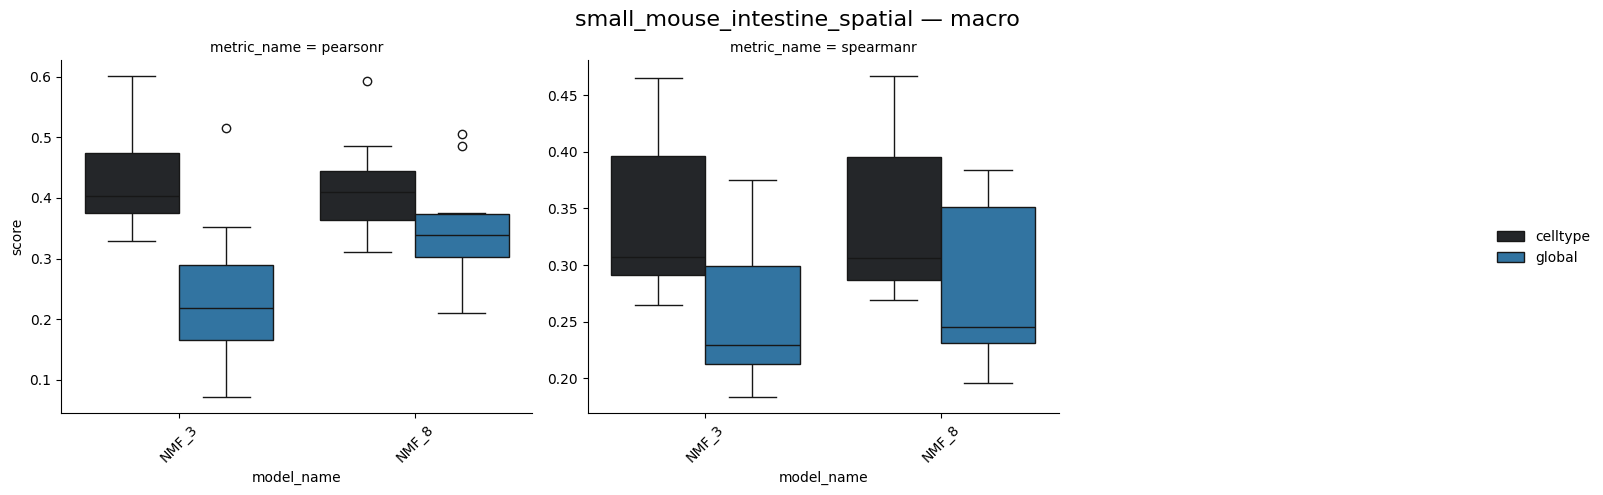

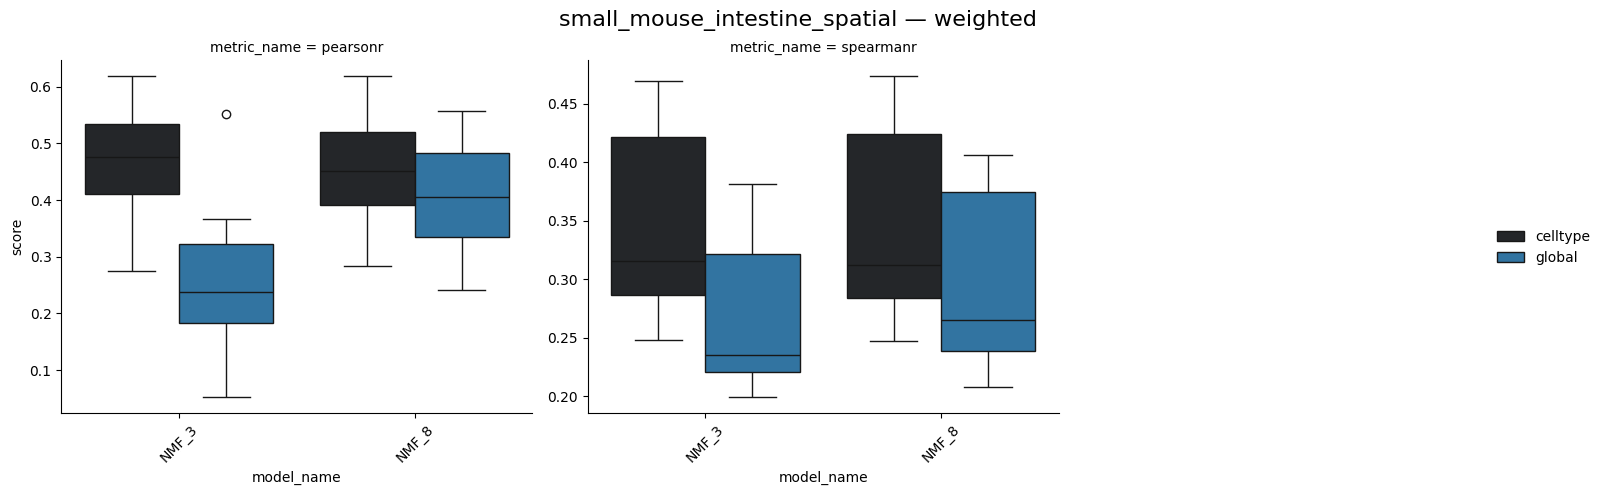

In [9]:
for (
    dataset_name,
    aggregation,
), df_dataset_aggregation in df.partition_by(
    ["dataset_name", "aggregation"], as_dict=True
).items():
    g = sns.FacetGrid(
        df_dataset_aggregation,
        col="metric_name",
        col_wrap=3,
        height=5,
        sharey=False,
    )
    g.map_dataframe(sns.boxplot, x="model_name", y="score", hue="prediction_scope")
    g.add_legend()
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=45)
    g.fig.suptitle(f"{dataset_name} — {aggregation}", fontsize=16)
    g.fig.tight_layout()
    g.fig.subplots_adjust(top=0.88)
    plt.show()